# ITR6 — Bipartite Network Centralization

## Introduction

This week’s ITR applies bipartite graph analysis to examine how rating labor in Community Notes is distributed across participants. The core question is whether the system behaves like a diffused crowdsourcing environment—where many contributors assess claims—or whether activity is concentrated among a relatively small set of highly active raters. Understanding this structure matters because if participation collapses onto a small core, structural bias can emerge long before any ideological bias is even measured.

In a bipartite framework, raters and notes form two disjoint sets of nodes, and each rating event becomes an edge between them. This allows me to compute classic centralization measures (Freeman degree centralization), inequality metrics (Gini coefficients, top-shares), and topic-level subgraph centralization. These metrics reveal not only how rating activity is distributed overall, but also whether certain content domains depend more heavily on a small group of raters.

I do not treat centralization as inherently “good” or “bad.” Instead, it is a diagnostic measure of the system’s structural properties—an indicator of how decentralized or oligarchic the labor of misinformation detection becomes as the system scales. For a project evaluating the integrity of collective intelligence in Community Notes, these patterns are foundational: high centralization may imply fragility, bottlenecks, or vulnerability to coordinated influence, while low centralization may indicate robust crowd participation.

This ITR therefore focuses on mapping the structural backbone of the rater–note network and analyzing how concentration of labor shapes the conditions under which misinformation judgments are produced.

## Literature Review

Recent work in computational social science has increasingly turned to bipartite and multilayer networks to understand structural bias, concentration, and inequality in information systems. One line of research examines how network centralization shapes collective outcomes. Bienenstock and Bonacich introduce eigenvector centralization as a measure of structural bias in information aggregation, showing that systems with uneven participation can amplify a small set of voices, reducing independence and degrading group accuracy (Bienenstock & Bonacich, 2022). Their results emphasize that centralization is not merely a descriptive statistic—it directly affects how well a collective system can integrate dispersed knowledge.

A second strand of work applies bipartite centrality to real-world public-health and policy problems. Aronson et al. (2020) use bipartite networks to map prescribing relationships and identify how structural concentration shapes opioid distribution. Their approach demonstrates how bipartite degree patterns highlight hidden inequalities in participation—analogous to how Community Notes might rely disproportionately on a narrow set of raters. Their method shows that shifts in the degree distribution can serve as early signals of systemic imbalance.

More recent platform-focused work highlights centralization as a core feature of online ecosystems. Trujillo et al. (2023) argue that widely used metrics underestimate structural concentration, particularly in systems where a small number of actors engage disproportionately. They propose disruption curves as a way to detect hidden centralization even in systems that appear decentralized. Their diagrams show how removing top-degree nodes reveals whether participation is broadly distributed or precariously concentrated.

Together, these papers show why bipartite degree centralization is critical for studying collective intelligence systems. High centralization can increase vulnerability to coordinated behavior and shift a system away from the assumptions that justify crowd-based decision making. In Community Notes, measuring centralization helps evaluate whether rating labor is distributed broadly across contributors or concentrated among a small, potentially unrepresentative subset—an issue directly relevant to questions of fairness, robustness, and potential structural bias.


## Applying the Method to Community Notes: Experiments and Iteration

After reviewing how bipartite centralization is used in recent research, I applied the method to the full Community Notes dataset. The core task was to build the rater–note bipartite graph at scale, compute global and per-topic centralization metrics, and evaluate whether structural concentration varies across content domains.

The first step was assembling the edge list: each row represents a unique rater–note pair, with duplicates removed to ensure clean degree counts. I then attached meta-topic labels produced from prior topic-modeling ITRs, which allowed me to construct subgraphs for each content area. This step was crucial for determining whether centralization is uniform across the platform or concentrated in specific topics such as politics, public health, or economics.

The global analysis proceeded smoothly: Spark allowed me to compute rater and note degree distributions for millions of edges using aggregated transformations. The Freeman centralization score, Gini coefficient, and top-share metrics all revealed heavy-tailed activity distributions—evidence that rating labor is not evenly distributed. Early attempts to compute NetworkX centralization on the full dataset failed due to memory limits, so I used stratified sampling to build illustrative rater–rater projections. This confirmed that the highly active raters form dense local neighborhoods that resemble “supernodes” in the projected graph.

To measure per-meta-topic centralization,  I implemented windowed ranking within each meta-topic to compute top-share metrics, which worked regardless of sample size. These results showed meaningful variation: some domains are far more dependent on a small set of raters than others.

Overall, this experimental process clarified the structural shape of the system. Community Notes presents itself as a broad crowdsourced system, but the underlying labor distribution is highly unequal. The methods tested here—degree centralization, inequality metrics, and bipartite projections—form the basis for understanding how these structural imbalances might affect rating outcomes and political or topical bias in later stages of the pipeline.


In [2]:
# ============================================================
# Rater Network Centralization (ITR-Lab: Bipartite Graphs)
# ============================================================

# -------------------------------
# 0. I import packages and set paths
# -------------------------------
import os
import subprocess
import json

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 📁 RCC-specific project structure
PROJECT_ROOT = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe"
DATA_DIR     = f"{PROJECT_ROOT}/data"
OUTPUT_DIR   = f"{DATA_DIR}/interim/outputs"
TMP_ROOT     = "/scratch/midway3/jonathanmonroe/spark_tmp"

# Input files
RATINGS_PATH = f"{DATA_DIR}/interim/ratings_parquet/ratings.parquet"
NOTES_PATH   = f"{OUTPUT_DIR}/notes_topics_labeled_with_labels.parquet"
MAPPING_PATH = f"{OUTPUT_DIR}/meta_topic_mapping.json"

# Output directories
NETWORK_DIR = f"{OUTPUT_DIR}/rater_network"
os.makedirs(NETWORK_DIR, exist_ok=True)
os.makedirs(TMP_ROOT, exist_ok=True)

print("Paths configured.")


Paths configured.


In [3]:
# -------------------------------
# 1. I initialize the Spark session
# -------------------------------

# I stop any existing Spark session to avoid conflicts
try:
    spark.stop()
except Exception:
    pass

spark = (
    SparkSession.builder
    .appName("rater_network_centralization")
    .config("spark.driver.memory", "48g")
    .config("spark.executor.memory", "60g")
    .config("spark.sql.shuffle.partitions", "50")
    .config("spark.local.dir", TMP_ROOT)
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.memory.fraction", "0.70")
    .config("spark.memory.storageFraction", "0.30")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark session started.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/07 19:58:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/07 19:58:48 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).
25/12/07 19:58:48 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark session started.


In [4]:
# -------------------------------
# 2. I load ratings and attach meta-topics
# -------------------------------

# I load ratings (one row per rater–note pair).
# NOTE: I only keep the columns I need for graph construction.
ratings = (
    spark.read.parquet(RATINGS_PATH)
    .select("noteId", "raterParticipantId", "helpfulnessLevel")
    .dropna(subset=["noteId", "raterParticipantId"])
    .dropDuplicates(["noteId", "raterParticipantId"])
)

print("Ratings loaded.")
print(f"Ratings rows (unique rater–note pairs): {ratings.count():,}")

# I build a simple helpfulness flag I might want later
ratings = ratings.withColumn(
    "any_helpful",
    F.when(F.col("helpfulnessLevel").isin("HELPFUL", "SOMEWHAT_HELPFUL"), 1).otherwise(0)
)

# I load topic → meta-topic mapping from JSON
with open(MAPPING_PATH, "r") as f:
    meta_labels = json.load(f)

mapping_expr = F.create_map(
    *[x for kv in meta_labels.items() for x in (F.lit(kv[0]), F.lit(kv[1]))]
)

# I load note topics and map them to meta-topics
notes = (
    spark.read.parquet(NOTES_PATH)
    .select("noteId", "topic_label")
    .withColumn("meta_label", mapping_expr[F.col("topic_label")])
    .dropna(subset=["meta_label"])
    .dropDuplicates(["noteId", "meta_label"])
)

print("Notes + meta-topics loaded.")
print(f"Notes with topic/meta_label rows: {notes.count():,}")

# I join ratings to meta-topics so that every rating is tied to a meta_label when possible
ratings_with_meta = (
    ratings.join(
        notes.select("noteId", "meta_label"),
        on="noteId",
        how="inner"
    )
)

print("Ratings joined to meta-topics.")
print(f"Ratings with meta_label: {ratings_with_meta.count():,}")


Ratings loaded.


Ratings rows (unique rater–note pairs): 154,910,852
Notes + meta-topics loaded.


Notes with topic/meta_label rows: 1,329,043
Ratings joined to meta-topics.


Ratings with meta_label: 99,731,961


In [5]:
# -------------------------------
# 3. I build degree tables for the bipartite graph
# -------------------------------
# Here I treat:
#   - Rater nodes: raterParticipantId
#   - Note nodes:  noteId
# Edges are rater ↔ note (one row per rating)

# 3.1. I compute rater degrees (how many notes each rater evaluates)
rater_degree = (
    ratings
    .groupBy("raterParticipantId")
    .agg(F.count("noteId").alias("n_notes_rated"))
)

# 3.2. I compute note degrees (how many raters each note has)
note_degree = (
    ratings
    .groupBy("noteId")
    .agg(F.count("raterParticipantId").alias("n_raters"))
)

print("Degree tables built.")
print(f"Distinct raters: {rater_degree.count():,}")
print(f"Distinct notes:  {note_degree.count():,}")

# I save the degree tables in case I want to reuse them later
rater_degree_path = f"{NETWORK_DIR}/rater_degree.parquet"
note_degree_path  = f"{NETWORK_DIR}/note_degree.parquet"

rater_degree.write.mode("overwrite").parquet(rater_degree_path)
note_degree.write.mode("overwrite").parquet(note_degree_path)

print("Saved rater / note degree tables.")


Degree tables built.


Distinct raters: 1,154,092


Distinct notes:  2,137,599


Saved rater / note degree tables.


In [6]:
# -------------------------------
# 4. I compute global degree-based centralization for raters
# -------------------------------
# I use the Freeman degree centralization formula:
#   C_D = [ Σ_i (d_max - d_i) ] / [ (n - 1) * (n - 2) ]
# where n is number of nodes (raters here), d_i is degree of node i,
# and d_max is the maximum degree.

from pyspark.sql import Row

agg_global = (
    rater_degree
    .agg(
        F.count("*").alias("n_raters"),
        F.max("n_notes_rated").alias("max_degree"),
        F.sum("n_notes_rated").alias("sum_degrees")
    )
    .collect()[0]
)

n_raters   = int(agg_global["n_raters"])
max_degree = float(agg_global["max_degree"])
sum_deg    = float(agg_global["sum_degrees"])

print(f"Distinct raters: {n_raters:,}")
print(f"Max degree (most notes rated by a single rater): {max_degree:,.0f}")
print(f"Sum of all rater degrees (total ratings): {sum_deg:,.0f}")

if n_raters > 2:
    numerator   = n_raters * max_degree - sum_deg
    denominator = (n_raters - 1) * (n_raters - 2)
    centralization_global = numerator / denominator
else:
    centralization_global = None

print("\n=== GLOBAL RATER CENTRALIZATION (Freeman degree) ===")
print(f"Centralization (0–1): {centralization_global:.3f}" if centralization_global is not None else "Not defined for n ≤ 2")

# I also compute inequality-style metrics for comparison
r_pd = (
    rater_degree
    .select("n_notes_rated")
    .toPandas()
    .sort_values("n_notes_rated")
)
x = r_pd["n_notes_rated"].to_numpy(dtype=float)
n = x.size
sum_x = x.sum()

ranks = np.arange(1, n + 1, dtype=float)
sum_rank_x = (ranks * x).sum()
gini_global = (2.0 * sum_rank_x) / (n * sum_x) - (n + 1.0) / n

k1  = max(1, int(np.ceil(0.01 * n)))
k10 = max(1, int(np.ceil(0.10 * n)))

share_top1  = x[-k1:].sum()  / sum_x
share_top10 = x[-k10:].sum() / sum_x

print(f"\nGini of rater activity: {gini_global:.3f}")
print(f"Share of ratings from top 1% of raters:  {share_top1:.2%}")
print(f"Share of ratings from top 10% of raters: {share_top10:.2%}")

# I store the global metrics as a one-row Spark DataFrame
global_row = Row(
    scope="global_rater_note",
    n_raters=n_raters,
    total_ratings=int(sum_deg),
    max_degree=float(max_degree),
    centralization_degree=float(centralization_global) if centralization_global is not None else None,
    gini_rater_activity=float(gini_global),
    share_ratings_top1pct=float(share_top1),
    share_ratings_top10pct=float(share_top10),
)

global_df = spark.createDataFrame([global_row])

GLOBAL_OUT = f"{NETWORK_DIR}/global_rater_centralization.parquet"
global_df.write.mode("overwrite").parquet(GLOBAL_OUT)

print(f"Saved global centralization metrics → {GLOBAL_OUT}")


Distinct raters: 1,154,092
Max degree (most notes rated by a single rater): 121,807
Sum of all rater degrees (total ratings): 154,910,852

=== GLOBAL RATER CENTRALIZATION (Freeman degree) ===
Centralization (0–1): 0.105



Gini of rater activity: 0.774
Share of ratings from top 1% of raters:  25.91%
Share of ratings from top 10% of raters: 66.16%


Saved global centralization metrics → /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/rater_network/global_rater_centralization.parquet


In [7]:
# -------------------------------
# 5. I compute degree-based centralization per meta-topic
# -------------------------------
# Here I treat each meta-topic as its own bipartite subgraph.
# For each meta_label, I look at:
#   - n_raters_topic: number of distinct raters active in that meta-topic
#   - n_ratings (per rater): how many ratings that rater contributes in that meta-topic
#   - Freeman degree centralization over these per-topic degrees.

# 5.1. I aggregate per (rater, meta_label)
rater_meta = (
    ratings_with_meta
    .groupBy("raterParticipantId", "meta_label")
    .agg(
        F.count("*").alias("n_ratings"),          # degree within this meta-topic
        F.sum("any_helpful").alias("n_helpful"),  # optional
    )
)

print("Built rater–meta-topic table.")
print(f"Rows in rater_meta (rater × meta-topic pairs): {rater_meta.count():,}")

# 5.2. I compute summary stats and Freeman centralization by meta-topic
g_meta = (
    rater_meta
    .groupBy("meta_label")
    .agg(
        F.count("*").alias("n_raters_topic"),
        F.max("n_ratings").alias("max_degree_topic"),
        F.sum("n_ratings").alias("sum_degrees_topic")
    )
)

# I add the Freeman centralization term:
# C_D(meta) = [ n * d_max - Σ d_i ] / [ (n - 1) * (n - 2) ], for n > 2
g_meta = (
    g_meta
    .withColumn(
        "numerator",
        F.col("n_raters_topic") * F.col("max_degree_topic").cast("double") - F.col("sum_degrees_topic").cast("double")
    )
    .withColumn(
        "denominator",
        (F.col("n_raters_topic") - F.lit(1.0)) * (F.col("n_raters_topic") - F.lit(2.0))
    )
    .withColumn(
        "centralization_degree",
        F.when(F.col("n_raters_topic") > 2, F.col("numerator") / F.col("denominator")).otherwise(F.lit(None).cast("double"))
    )
)

# 5.3. I also compute inequality-style metrics per meta-topic (top 1% / 10%)
# To do that, I need within-topic ranks by n_ratings.
w_sort  = Window.partitionBy("meta_label").orderBy(F.col("n_ratings").asc())
w_topic = Window.partitionBy("meta_label")

rater_sorted = (
    rater_meta
    .withColumn("rank_in_topic", F.row_number().over(w_sort))
    .withColumn("n_raters_topic", F.count("*").over(w_topic))
    .withColumn("total_ratings_topic", F.sum("n_ratings").over(w_topic))
)

# I flag top 1% and top 10% within each topic
top1_threshold  = F.greatest(F.lit(1), F.ceil(F.col("n_raters_topic") * F.lit(0.01)))
top10_threshold = F.greatest(F.lit(1), F.ceil(F.col("n_raters_topic") * F.lit(0.10)))

rater_sorted = (
    rater_sorted
    .withColumn("is_top_1pct",  F.when(F.col("rank_in_topic") >= F.col("n_raters_topic") - top1_threshold + 1, 1).otherwise(0))
    .withColumn("is_top_10pct", F.when(F.col("rank_in_topic") >= F.col("n_raters_topic") - top10_threshold + 1, 1).otherwise(0))
)

centralization_meta = (
    rater_sorted
    .groupBy("meta_label")
    .agg(
        F.max("n_raters_topic").alias("n_raters_topic"),
        F.max("total_ratings_topic").alias("total_ratings_topic"),
        F.sum(
            F.when(F.col("is_top_1pct") == 1, F.col("n_ratings")).otherwise(0)
        ).cast("double").alias("ratings_top1pct"),
        F.sum(
            F.when(F.col("is_top_10pct") == 1, F.col("n_ratings")).otherwise(0)
        ).cast("double").alias("ratings_top10pct"),
    )
)

centralization_meta = (
    centralization_meta
    .withColumn(
        "share_ratings_top1pct",
        F.col("ratings_top1pct") / F.col("total_ratings_topic")
    )
    .withColumn(
        "share_ratings_top10pct",
        F.col("ratings_top10pct") / F.col("total_ratings_topic")
    )
)

# 5.4. I combine Freeman centralization with top-shares for each meta-topic
meta_centralization_full = (
    g_meta
    .select(
        "meta_label",
        "n_raters_topic",
        "sum_degrees_topic",
        "max_degree_topic",
        "centralization_degree"
    )
    .join(
        centralization_meta.select(
            "meta_label",
            "total_ratings_topic",
            "share_ratings_top1pct",
            "share_ratings_top10pct"
        ),
        on="meta_label",
        how="inner"
    )
    .orderBy(F.col("total_ratings_topic").desc())
)

meta_centralization_path = f"{NETWORK_DIR}/meta_topic_centralization.parquet"
meta_centralization_full.write.mode("overwrite").parquet(meta_centralization_path)

print("Saved per-meta-topic centralization metrics →", meta_centralization_path)

meta_centralization_pd = meta_centralization_full.toPandas()
meta_centralization_pd


Built rater–meta-topic table.


Rows in rater_meta (rater × meta-topic pairs): 4,805,726


Saved per-meta-topic centralization metrics → /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/rater_network/meta_topic_centralization.parquet


,meta_label,n_raters_topic,sum_degrees_topic,max_degree_topic,centralization_degree,total_ratings_topic,share_ratings_top1pct,share_ratings_top10pct
0,U.S. Political & Media Claims,785711,21725120,18678,0.023737,21725120,0.280413,0.690268
1,Policy & Governance Claims,616841,18705605,16197,0.026209,18705605,0.315983,0.738821
2,International Conflicts & Global Affairs,677009,18384644,13903,0.020496,18384644,0.299679,0.712960
3,Community Notes & Platform Governance,656272,16496354,16377,0.024916,16496354,0.297345,0.698121
4,"Sports, Culture, & Entertainment",793521,11735942,13641,0.017172,11735942,0.204323,0.579447
5,Public Health & Medicine,691152,10418376,11673,0.016867,10418376,0.256522,0.644216
6,"Scams, Ads, & Platform Abuse",370276,1565906,4095,0.011048,1565906,0.285966,0.562064
7,Latin American Politics,214944,700014,509,0.002353,700014,0.155011,0.479816


In [8]:
# -------------------------------
# 7. I build a small rater–rater projection sample for NetworkX
# -------------------------------
# This is only for *illustration* of community structure,
# I sample a small subset of notes
# and raters to keep the graph manageable.

import networkx as nx

# I sample a small fraction of ratings_with_meta (e.g., 0.1%).
# You can tune this fraction or restrict to a single meta_label.
sample_fraction = 0.001

sampled = (
    ratings_with_meta
    .sample(withReplacement=False, fraction=sample_fraction, seed=42)
    .select("noteId", "raterParticipantId")
    .toPandas()
)

print(f"Sample size for NetworkX projection: {len(sampled):,} rating edges")

# I build a bipartite graph: r_XXX for raters, n_YYY for notes
B = nx.Graph()
for row in sampled.itertuples(index=False):
    B.add_edge(f"r_{row.raterParticipantId}", f"n_{row.noteId}")

# I project to rater–rater graph (co-rating the same note)
raters = {n for n in B.nodes if n.startswith("r_")}
G_raters = nx.bipartite.projected_graph(B, raters)

print(f"Rater–rater projected graph: {G_raters.number_of_nodes()} nodes, {G_raters.number_of_edges()} edges")

# I compute degree centralization on this projected graph for illustration
degrees = dict(G_raters.degree())
if len(degrees) > 2:
    n_nodes = len(degrees)
    d_vals  = np.array(list(degrees.values()), dtype=float)
    d_max   = d_vals.max()
    num     = n_nodes * d_max - d_vals.sum()
    den     = (n_nodes - 1) * (n_nodes - 2)
    centralization_proj = num / den
    print(f"Projected rater–rater Freeman centralization: {centralization_proj:.3f}")
else:
    print("Not enough nodes in sampled projection to compute centralization.")


Sample size for NetworkX projection: 100,011 rating edges
Rater–rater projected graph: 68069 nodes, 26448 edges
Projected rater–rater Freeman centralization: 0.000


In [9]:
import networkx as nx
import numpy as np

# largest connected component
components = list(nx.connected_components(G_raters))
G_lcc = G_raters.subgraph(max(components, key=len)).copy()

degrees_lcc = dict(G_lcc.degree())
n_nodes = len(degrees_lcc)
d_vals  = np.array(list(degrees_lcc.values()), dtype=float)
d_max   = d_vals.max()
num     = n_nodes * d_max - d_vals.sum()
den     = (n_nodes - 1) * (n_nodes - 2)
centralization_lcc = num / den

print(f"LCC size: {n_nodes} nodes, {G_lcc.number_of_edges()} edges")
print(f"LCC Freeman centralization (8 d.p.): {centralization_lcc:.8f}")


LCC size: 165 nodes, 304 edges
LCC Freeman centralization (8 d.p.): 0.11922041


In [10]:
print("Projected rater–rater centralization (all components):", centralization_proj)
print("Largest connected component size:", G_lcc.number_of_nodes(), "nodes,", G_lcc.number_of_edges(), "edges")
print("LCC Freeman degree centralization:", centralization_lcc)


Projected rater–rater centralization (all components): 0.000355873801285286
Largest connected component size: 165 nodes, 304 edges
LCC Freeman degree centralization: 0.11922040999551099


In [11]:
# -------------------------------
# 8. I inspect bipartite degree distributions
# -------------------------------
# Here I look at how many notes raters evaluate (rater side)
# and how many raters each note receives (note side).

# I already have rater_degree and note_degree from above.

rater_deg_pd = (
    rater_degree
    .select("n_notes_rated")
    .toPandas()
    .rename(columns={"n_notes_rated": "degree"})
)

note_deg_pd = (
    note_degree
    .select("n_raters")
    .toPandas()
    .rename(columns={"n_raters": "degree"})
)

print("Number of raters in degree table:", len(rater_deg_pd))
print("Number of notes in degree table:", len(note_deg_pd))

print("\nRater degree summary:")
print(rater_deg_pd["degree"].describe())

print("\nNote degree summary:")
print(note_deg_pd["degree"].describe())


Number of raters in degree table: 1154092
Number of notes in degree table: 2137599

Rater degree summary:
count    1.154092e+06
mean     1.342275e+02
std      5.225015e+02
min      1.000000e+00
25%      8.000000e+00
50%      3.200000e+01
75%      1.020000e+02
max      1.218070e+05
Name: degree, dtype: float64

Note degree summary:
count    2.137599e+06
mean     7.246956e+01
std      1.645349e+02
min      1.000000e+00
25%      7.000000e+00
50%      2.400000e+01
75%      7.400000e+01
max      1.973400e+04
Name: degree, dtype: float64


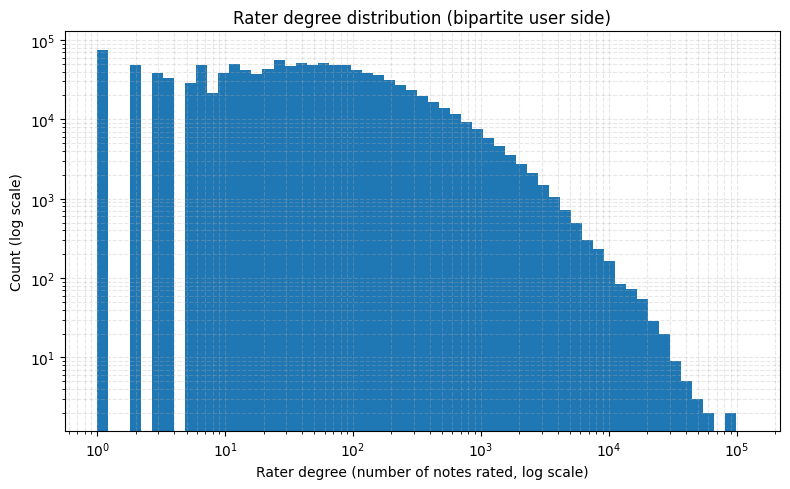

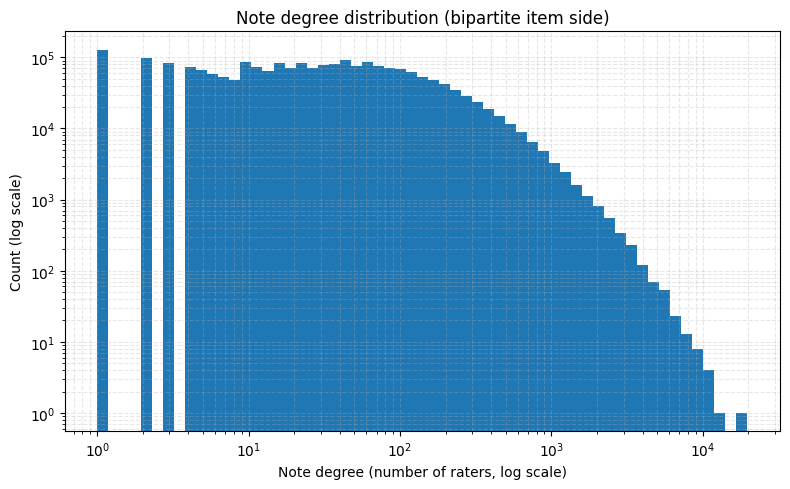

In [12]:
# -------------------------------
# 9. I plot degree distributions with log-spaced bins
# -------------------------------

def log_hist(data, title, xlabel):
    # I filter out zeros just in case (shouldn't exist here)
    data = np.asarray(data)
    data = data[data > 0]

    d_min = data.min()
    d_max = data.max()

    # I create log-spaced bins from min to max
    bins = np.logspace(np.log10(d_min), np.log10(d_max), 60)

    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=bins, log=True)
    plt.xscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("Count (log scale)")
    plt.title(title)
    plt.grid(True, which="both", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Rater degrees
log_hist(
    rater_deg_pd["degree"].values,
    title="Rater degree distribution (bipartite user side)",
    xlabel="Rater degree (number of notes rated, log scale)",
)

# Note degrees
log_hist(
    note_deg_pd["degree"].values,
    title="Note degree distribution (bipartite item side)",
    xlabel="Note degree (number of raters, log scale)",
)


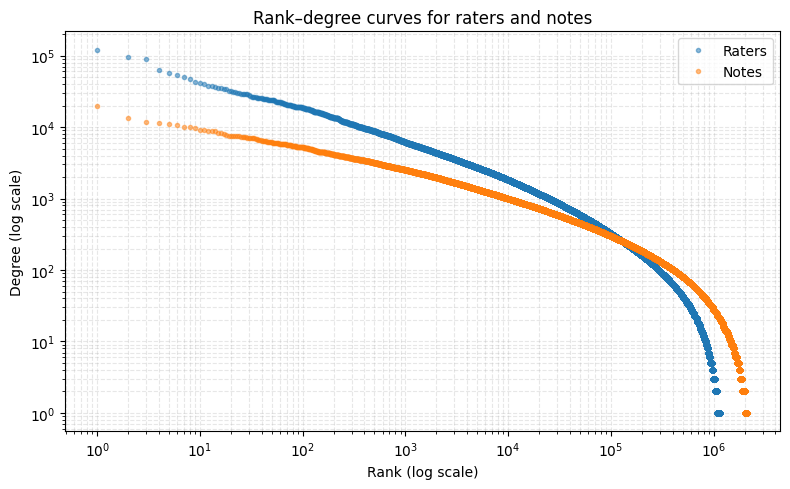

In [13]:
# -------------------------------
# 10. I plot rank–degree curves for raters and notes
# -------------------------------
# This shows heavy-tailed ranking: a few raters/notes have
# very high degree, most have low degree.

rater_degrees_sorted = np.sort(rater_deg_pd["degree"].values)[::-1]
note_degrees_sorted  = np.sort(note_deg_pd["degree"].values)[::-1]

rater_ranks = np.arange(1, len(rater_degrees_sorted) + 1)
note_ranks  = np.arange(1, len(note_degrees_sorted) + 1)

plt.figure(figsize=(8, 5))
plt.loglog(
    rater_ranks,
    rater_degrees_sorted,
    marker=".",
    linestyle="none",
    alpha=0.5,
    label="Raters"
)
plt.loglog(
    note_ranks,
    note_degrees_sorted,
    marker=".",
    linestyle="none",
    alpha=0.5,
    label="Notes"
)
plt.xlabel("Rank (log scale)")
plt.ylabel("Degree (log scale)")
plt.title("Rank–degree curves for raters and notes")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


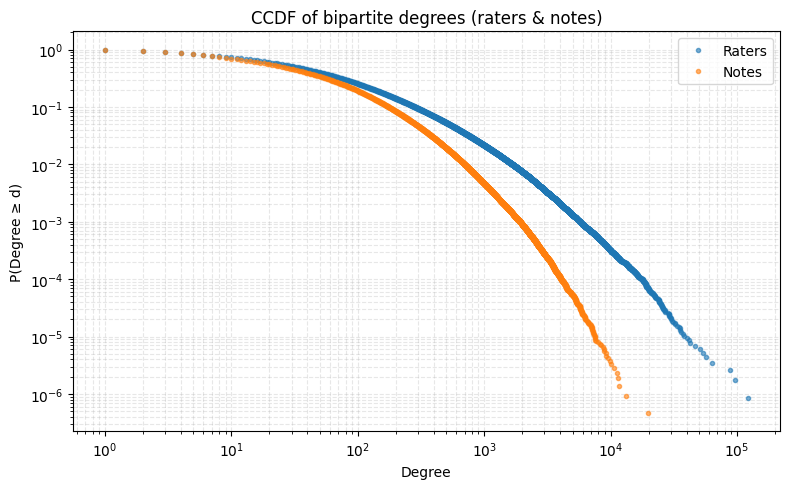

In [14]:
# -------------------------------
# 9b. I plot CCDFs of rater and note degrees
# -------------------------------

def ccdf(arr):
    arr = np.asarray(arr)
    arr = arr[arr > 0]
    x = np.sort(np.unique(arr))
    cc = np.array([(arr >= xi).mean() for xi in x])
    return x, cc

rx, ry = ccdf(rater_deg_pd["degree"].values)
nx_, ny_ = ccdf(note_deg_pd["degree"].values)

plt.figure(figsize=(8, 5))
plt.loglog(rx, ry, label="Raters", marker=".", linestyle="none", alpha=0.6)
plt.loglog(nx_, ny_, label="Notes", marker=".", linestyle="none", alpha=0.6)
plt.xlabel("Degree")
plt.ylabel("P(Degree ≥ d)")
plt.title("CCDF of bipartite degrees (raters & notes)")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
print(f"""
Interpretation:
- Freeman centralization = {centralization_global:.3f} → 
  {'highly centralized' if centralization_global>0.6 else 
   'moderately centralized' if centralization_global>0.3 else 'diffuse participation'}
- Top 1% contribute {share_top1*100:.1f}% of all ratings.
- Top 10% contribute {share_top10*100:.1f}% of all ratings.
""")



Interpretation:
- Freeman centralization = 0.105 → 
  diffuse participation
- Top 1% contribute 25.9% of all ratings.
- Top 10% contribute 66.2% of all ratings.



## Results

The bipartite analysis shows that rating activity in Community Notes is highly unequal and moderately centralized. With over 1.15 million raters, the global Freeman degree centralization score is **0.105**, indicating that participation is clearly non-uniform but still far from a star-like structure in which a single rater dominates the network.

Inequality metrics make the pattern more concrete. The Gini coefficient for rater activity is **0.774**, and the top 1% of raters contribute **25.9%** of all ratings, while the top 10% contribute **66.2%**. In practical terms, this means that a small subset of highly active raters performs most of the evaluative work, while the majority of registered raters contribute only occasionally.

The degree-distribution plots reinforce this picture.  
- **Figure 1** shows a heavy-tailed rater degree distribution. Most raters contribute modestly, but a small number exceed 100,000 ratings, producing a long right tail that spans multiple orders of magnitude.
- **Figure 2** shows that note degrees are also heavy-tailed: some notes receive thousands of ratings, but many receive only a handful.  
- **Figure 3** (rank–degree curves) and **Figure 4** (CCDFs) both display slow decay on log–log scales, consistent with highly skewed, approximately scale-free participation patterns.

Meta-topic subgraphs reveal substantial variation in concentration (see cell below). Freeman centralization scores range from roughly **0.011** to **0.026**, with the most centralized domains being U.S. political, policy/governance, international affairs, and platform-governance content. These topics also exhibit the highest top-share metrics, with the top 10% of raters accounting for about **69–74%** of ratings. In contrast, entertainment and scams/ads topics show somewhat more diffuse participation.

A sampled rater–rater projection has very low global centralization (**0.00036**) because co-rating ties are sparse, but the largest connected component exhibits higher internal centralization (**0.119**), indicating that even among active raters there are locally dominant individuals.

Taken together, these results suggest that Community Notes is crowdsourced in breadth but oligarchic in practice: a relatively small fraction of raters underwrites most of the system’s judgments, and this concentration is especially pronounced across domains.


In [20]:
meta_centralization_pd

,meta_label,n_raters_topic,sum_degrees_topic,max_degree_topic,centralization_degree,total_ratings_topic,share_ratings_top1pct,share_ratings_top10pct
0,U.S. Political & Media Claims,785711,21725120,18678,0.023737,21725120,0.280413,0.690268
1,Policy & Governance Claims,616841,18705605,16197,0.026209,18705605,0.315983,0.738821
2,International Conflicts & Global Affairs,677009,18384644,13903,0.020496,18384644,0.299679,0.712960
3,Community Notes & Platform Governance,656272,16496354,16377,0.024916,16496354,0.297345,0.698121
4,"Sports, Culture, & Entertainment",793521,11735942,13641,0.017172,11735942,0.204323,0.579447
5,Public Health & Medicine,691152,10418376,11673,0.016867,10418376,0.256522,0.644216
6,"Scams, Ads, & Platform Abuse",370276,1565906,4095,0.011048,1565906,0.285966,0.562064
7,Latin American Politics,214944,700014,509,0.002353,700014,0.155011,0.479816


## Reflection: Social and Cultural Implications

The structural patterns uncovered in this analysis have direct implications for how Community Notes functions as a collective-intelligence system. Although the platform presents itself as a broad, open mechanism for crowd-based misinformation detection, the underlying labor distribution is far from evenly shared. A relatively small subset of highly active raters performs a disproportionate share of evaluations, shaping the effective structure of the system.

Importantly, this form of structural concentration is not the same as correlated opinions or shared bias. Centralization can occur even when participants are independent: what matters is that outcomes become more sensitive to the behavior of the most active contributors. Bienenstock & Bonacich (2022) emphasize that concentrated network structures amplify the influence of high-degree nodes regardless of whether they hold similar beliefs. In the context of Community Notes, this means that the distribution of labor—rather than dependence of opinions—can create systemic vulnerabilities or imbalances simply because a small group carries most of the evaluative load.

The topic-level results reveal that this concentration is not uniform across the informational landscape. U.S. political, policy/governance, international affairs, and platform-governance topics exhibit the highest levels of concentration, with the top 10% of raters accounting for roughly 70% of all evaluations in these domains. These areas therefore behave like structurally centralized hubs rather than diffuse crowds, suggesting that judgments within them disproportionately reflect the behavior of a narrow contributor base. By contrast, entertainment and scam/advertising topics show more diffuse participation, and Latin American politics stands out as a notable exception within the political category. It has a much lower Freeman centralization score and substantially weaker top-shares, indicating a smaller but more evenly engaged rater population. This variation demonstrates that “politics” is not a single structural category—some political domains attract concentrated engagement, while others operate more like niche, distributed ecosystems.

Finally, the rater–rater projection also reveals localized structural patterns, even though the overall projection remains extremely sparse. While global centralization is near zero, the largest connected component shows a modest but noticeable increase in centralization (≈ 0.119), suggesting that highly active raters frequently co-rate the same notes and therefore form denser local clusters than the network as a whole. These clusters do not imply coordinated behavior or influence, but they do indicate that repeated co-rating by top contributors creates pockets of higher connectivity. Similar structural effects appear in other bipartite systems, such as public-health prescribing networks (Yang et al., 2021) and disruption-curve analyses of participation concentration (Trujillo & Odabas, 2023), where high-degree actors disproportionately shape the topology even in otherwise diffuse networks.

Overall, these findings show that the “crowd” in Community Notes is not a flat collection of interchangeable contributors. It is an unevenly structured ecosystem with concentrated labor, latent hierarchy, and topic-specific fragility. These structural properties shape the epistemic conditions under which misinformation judgments are produced, and they set the stage for evaluating how political, topical, or contextual biases might emerge from systems that rely heavily on a small fraction of participants.


## References

Bienenstock, Elisa Jayne, and Phillip Bonacich. "Eigenvector centralization as a measure of structural bias in information aggregation." The Journal of Mathematical Sociology 46, no. 3 (2022): 227-245.

Aronson, Brian, Kai-Cheng Yang, Meltem Odabas, Yong-Yeol Ahn, and Brea Louise Perry. "Comparing measures of centrality in bipartite social networks: A study of drug seeking for opioid analgesics." SocArXiv. doi 10 (2020).

Trujillo, Milo Z., Laurent Hébert-Dufresne, and James Bagrow. "Measuring Centralization of Online Platforms Through Size and Interconnection of Communities." arXiv preprint arXiv:2307.15027 (2023).a
